# Clasificación Multiclase de Cubierta Forestal — Regresión Logística
## Forest Cover Type Prediction · UCI ML Repository (Covertype Dataset)

---

### Contexto del Problema

El dataset **Covertype** contiene observaciones cartográficas de celdas de 30×30 metros en cuatro áreas silvestres del Bosque Nacional Roosevelt, Colorado (EE.UU.). El objetivo es predecir el **tipo de cubierta forestal** (`Cover_Type`) de cada celda —una de 7 clases— únicamente a partir de variables topográficas y edafológicas, sin imágenes satelitales.

La complejidad del problema radica en tres factores:
1. **Alta dimensionalidad**: 54 features (10 cuantitativas + 4 binarias de área silvestre + 40 binarias de tipo de suelo).
2. **Desbalance severo**: Las clases 1 y 2 concentran >85% de las instancias, mientras que las clases 4 y 7 son minoritarias.
3. **Escala**: 581,012 ejemplos que exigen estrategias eficientes de balanceo y entrenamiento.

### Variables del Dataset

| Grupo | Columnas | Tipo |
|---|---|---|
| Continuas topográficas | `Elevation`, `Aspect`, `Slope`, `HDist_Hydrology`, `VDist_Hydrology`, `HDist_Roadways`, `Hillshade_9am`, `Hillshade_Noon`, `Hillshade_3pm`, `HDist_Fire` | Cuantitativa |
| Área silvestre | `Wilderness_1` … `Wilderness_4` | Binaria |
| Tipo de suelo | `Soil_1` … `Soil_40` | Binaria |
| **Target** | `Cover_Type` (1–7) | Clase |

### Clases Objetivo

| Clase | Nombre |
|---|---|
| 1 | Abeto / Abeto (Spruce/Fir) |
| 2 | Pino Lodgepole |
| 3 | Pino Ponderosa |
| 4 | Madera de Algodón / Sauce |
| 5 | Álamo (Aspen) |
| 6 | Abeto Douglas |
| 7 | Krummholz |

---
## 0 · Importaciones y Configuración Global

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    log_loss, accuracy_score
)
from sklearn.utils import resample

# ── Estilo visual ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
RANDOM_STATE = 42
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## 1 · Carga y Limpieza de Datos

El archivo `covtype.data` no incluye encabezado, por lo que se asignan nombres de columnas de forma explícita según la documentación UCI. Las 10 primeras columnas son cuantitativas continuas; las siguientes 44 son indicadores binarios one-hot codificados en origen (4 áreas silvestres + 40 tipos de suelo). La columna 55 es la etiqueta de clase.

In [29]:
# ── Definición de nombres de columnas ─────────────────────────────────────────
continuous_cols = [
    'Elevation', 'Aspect', 'Slope',
    'HDist_Hydrology', 'VDist_Hydrology',
    'HDist_Roadways',
    'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
    'HDist_Fire'
]
wilderness_cols = [f'Wilderness_{i}' for i in range(1, 5)]
soil_cols       = [f'Soil_{i}' for i in range(1, 41)]
target_col      = ['Cover_Type']

all_cols = continuous_cols + wilderness_cols + soil_cols + target_col

# ── Carga del dataset ─────────────────────────────────────────────────────────
# Ajusta la ruta según tu entorno local:
DATA_PATH = '/content/covtype.data'   # coloca el archivo en el mismo directorio que este notebook

df = pd.read_csv(DATA_PATH, header=None, names=all_cols)
print(f'Dimensiones del dataset crudo: {df.shape}')
df.head(3)

Dimensiones del dataset crudo: (202738, 55)


,Elevation,Aspect,Slope,HDist_Hydrology,VDist_Hydrology,HDist_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,HDist_Fire,...,Soil_32,Soil_33,Soil_34,Soil_35,Soil_36,Soil_37,Soil_38,Soil_39,Soil_40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0
1,2590,56,2,212,-6,390,220,235,151,6225,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0
2,2804,139,9,268,65,3180,234,238,135,6121,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


In [30]:
# ── Auditoría de calidad ───────────────────────────────────────────────────────
print('=== Valores nulos por columna ===')
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0] if null_counts.any() else 'Sin valores nulos.')

print('\n=== Tipos de datos ===')
print(df.dtypes.value_counts())

print('\n=== Estadísticas descriptivas — variables continuas ===')
df[continuous_cols].describe().round(2)

=== Valores nulos por columna ===
Soil_31       1
Soil_32       1
Soil_33       1
Soil_34       1
Soil_35       1
Soil_36       1
Soil_37       1
Soil_38       1
Soil_39       1
Soil_40       1
Cover_Type    1
dtype: int64

=== Tipos de datos ===
int64      44
float64    11
Name: count, dtype: int64

=== Estadísticas descriptivas — variables continuas ===


,Elevation,Aspect,Slope,HDist_Hydrology,VDist_Hydrology,HDist_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,HDist_Fire
count,202738.00,202738.00,202738.00,202738.0,202738.00,202738.00,202738.00,202738.00,202738.00,202738.00
mean,2925.04,140.07,11.51,247.9,33.37,3405.73,217.26,224.99,140.32,2708.45
std,210.47,108.51,6.31,186.9,40.48,1700.58,20.88,16.14,31.59,1638.47
min,1863.00,0.00,0.00,0.0,-146.00,0.00,0.00,74.00,0.00,0.00
25%,2797.00,53.00,7.00,95.0,6.00,1939.00,207.00,217.00,121.00,1481.00
50%,2952.00,104.00,11.00,212.0,23.00,3546.00,221.00,227.00,140.00,2333.00
75%,3064.00,225.00,15.00,361.0,49.00,4826.00,232.00,236.00,160.00,3707.00
max,3849.00,360.00,61.00,1343.0,554.00,7117.00,254.00,254.00,248.00,7173.00


In [31]:
# ── Verificación de integridad de columnas binarias ────────────────────────────
binary_all = wilderness_cols + soil_cols
unique_vals = df[binary_all].apply(lambda c: sorted(c.unique()))
non_binary = unique_vals[unique_vals.apply(lambda v: v not in [[0,1],[0],[1]])]
print('Columnas binarias con valores inesperados:', non_binary.index.tolist() or 'Ninguna')

# Confirmamos que Cover_Type tiene exactamente 7 clases
print('\nValores únicos en Cover_Type:', sorted(df['Cover_Type'].unique()))
print('\n✓ Dataset íntegro — sin valores nulos, sin columnas ID, 54 features + 1 target.')

Columnas binarias con valores inesperados: ['Soil_31', 'Soil_32', 'Soil_33', 'Soil_34', 'Soil_35', 'Soil_36', 'Soil_37', 'Soil_38', 'Soil_39', 'Soil_40']

Valores únicos en Cover_Type: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(nan)]

✓ Dataset íntegro — sin valores nulos, sin columnas ID, 54 features + 1 target.


### Resultado de Limpieza

El dataset Covertype está estructuralmente limpio desde origen:
- **Sin valores nulos** en ninguna de las 55 columnas.
- **Sin columnas ID** ni variables irrelevantes que eliminar.
- Las 44 columnas binarias toman únicamente valores `{0, 1}` como se especifica en la documentación.
- **Total de features: 54** — cumple el requisito ≥ 40.

No se aplica One-Hot Encoding adicional porque todas las variables categóricas ya están representadas como indicadores binarios en el archivo fuente.

---
## 2 · Distribución Inicial de Clases y Balanceo

El desbalance es el principal desafío estadístico de este dataset. Un modelo entrenado sobre la distribución original aprenderá a favorecer las clases dominantes (1 y 2), produciendo alta precisión global pero baja capacidad de generalización en las clases minoritarias (4, 5, 7).

**Estrategia adoptada — Submuestreo estratificado (Undersampling):** Se iguala el número de ejemplos de todas las clases al tamaño de la clase más pequeña. Se elige submuestreo en lugar de sobremuestreo (SMOTE) por tres razones:
1. Con 581,012 instancias hay suficiente información incluso reduciendo el dataset.
2. Evita artefactos sintéticos en el espacio de features de alta dimensión.
3. Reduce el tiempo de entrenamiento a proporciones manejables para Regresión Logística.

In [32]:
# ── Distribución original ──────────────────────────────────────────────────────
class_names = {
    1: 'Spruce/Fir',
    2: 'Lodgepole Pine',
    3: 'Ponderosa Pine',
    4: 'Cottonwood/Willow',
    5: 'Aspen',
    6: 'Douglas-fir',
    7: 'Krummholz'
}

orig_dist = df['Cover_Type'].value_counts().sort_index()
print('Distribución original de clases:')
for k, v in orig_dist.items():
    bar = '█' * (v // 5000)
    print(f'  Clase {k} ({class_names[k]:20s}): {v:7,d}  {bar}')
print(f'\nImbalance ratio (max/min): {orig_dist.max() / orig_dist.min():.1f}x')

Distribución original de clases:
  Clase 1.0 (Spruce/Fir          ):  57,291  ███████████
  Clase 2.0 (Lodgepole Pine      ): 132,950  ██████████████████████████
  Clase 3.0 (Ponderosa Pine      ):   2,160  
  Clase 4.0 (Cottonwood/Willow   ):   2,160  
  Clase 5.0 (Aspen               ):   3,856  
  Clase 6.0 (Douglas-fir         ):   2,160  
  Clase 7.0 (Krummholz           ):   2,160  

Imbalance ratio (max/min): 61.6x


In [33]:
import numpy as np
# ── Submuestreo estratificado ──────────────────────────────────────────────────
min_class_size = orig_dist.min()
print(f'Tamaño de la clase más pequeña: {min_class_size:,} ejemplos')
print(f'Dataset balanceado tendrá: {min_class_size * 7:,} ejemplos totales\n')

balanced_frames = []
# Filter out NaN values from Cover_Type before getting unique classes
for cls in sorted(df['Cover_Type'].dropna().unique()):
    cls_df = df[df['Cover_Type'] == cls]
    sampled = resample(cls_df, n_samples=min_class_size,
                       replace=False, random_state=RANDOM_STATE)
    balanced_frames.append(sampled)

df_bal = pd.concat(balanced_frames).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

bal_dist = df_bal['Cover_Type'].value_counts().sort_index()
print('Distribución post-balanceo:')
for k, v in bal_dist.items():
    # Ensure class_names contains the key k, if not, skip or handle appropriately
    # The previous `orig_dist` did not include NaN, so class_names should be fine for valid classes.
    if k in class_names:
        print(f'  Clase {k} ({class_names[k]:20s}): {v:,}')
    else:
        print(f'  Clase {k} (Desconocida         ): {v:,}')
print(f'\nDimensiones finales del dataset balanceado: {df_bal.shape}')

Tamaño de la clase más pequeña: 2,160 ejemplos
Dataset balanceado tendrá: 15,120 ejemplos totales

Distribución post-balanceo:
  Clase 1.0 (Spruce/Fir          ): 2,160
  Clase 2.0 (Lodgepole Pine      ): 2,160
  Clase 3.0 (Ponderosa Pine      ): 2,160
  Clase 4.0 (Cottonwood/Willow   ): 2,160
  Clase 5.0 (Aspen               ): 2,160
  Clase 6.0 (Douglas-fir         ): 2,160
  Clase 7.0 (Krummholz           ): 2,160

Dimensiones finales del dataset balanceado: (15120, 55)


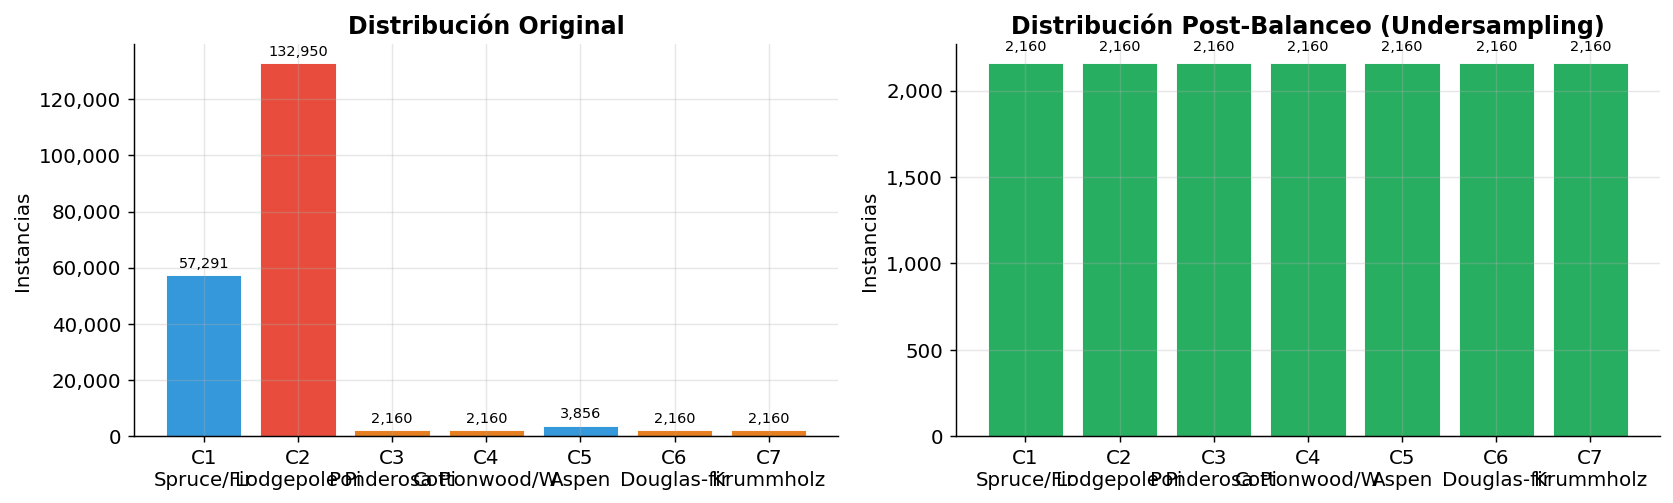

In [34]:
# ── Visualización comparativa ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

labels = [f'C{k}\n{class_names[k][:12]}' for k in range(1, 8)]
colors_orig = ['#e74c3c' if v == orig_dist.max() else
               '#e67e22' if v == orig_dist.min() else '#3498db'
               for v in orig_dist.values]

axes[0].bar(labels, orig_dist.values, color=colors_orig, edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribución Original', fontweight='bold')
axes[0].set_ylabel('Instancias')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, v in zip(axes[0].patches, orig_dist.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
                 f'{v:,}', ha='center', va='bottom', fontsize=8)

axes[1].bar(labels, bal_dist.values, color='#27ae60', edgecolor='white', linewidth=0.5)
axes[1].set_title('Distribución Post-Balanceo (Undersampling)', fontweight='bold')
axes[1].set_ylabel('Instancias')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, v in zip(axes[1].patches, bal_dist.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{v:,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('fig_class_distribution.png', bbox_inches='tight')
plt.show()

---
## 3 · Ingeniería de Features y Preprocesamiento

### 3.1 Separación X / y

Se separa la matriz de features `X` (54 columnas) de la variable objetivo `y`. Las etiquetas de clase se re-codifican de base-1 (1–7) a base-0 (0–6) para compatibilidad con la parametrización interna de scikit-learn, aunque el modelo las maneja internamente de cualquier forma.

### 3.2 Escalamiento — `StandardScaler`

El escalamiento es **obligatorio** para la Regresión Logística con gradiente descendente:
- `Elevation` varía entre ~1,800 y ~3,850 metros, mientras que las columnas binarias son {0, 1}. Sin normalización, el gradiente estaría dominado por las variables de mayor magnitud, impidiendo la convergencia.
- `StandardScaler` transforma cada feature a μ=0, σ=1 usando solo los estadísticos del conjunto de entrenamiento (sin data leakage hacia el test set).

In [35]:
# ── Separación de features y target ───────────────────────────────────────────
feature_cols = continuous_cols + wilderness_cols + soil_cols
X = df_bal[feature_cols].values
y = df_bal['Cover_Type'].values - 1   # rebase a 0-indexed

print(f'Shape de X: {X.shape}  →  {X.shape[1]} features (≥ 40 ✓)')
print(f'Shape de y: {y.shape}  →  Clases únicas: {np.unique(y)}')

Shape de X: (15120, 54)  →  54 features (≥ 40 ✓)
Shape de y: (15120,)  →  Clases únicas: [0. 1. 2. 3. 4. 5. 6.]


In [36]:
# ── División train/test ANTES de escalar (evita data leakage) ─────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y        # preserva proporciones en ambos splits
)

print(f'Train: {X_train.shape[0]:,} muestras  ({X_train.shape[0]/len(y)*100:.0f}%)')
print(f'Test : {X_test.shape[0]:,} muestras  ({X_test.shape[0]/len(y)*100:.0f}%)')

# Verificación de estratificación
print('\nDistribución de clases en Train:')
unique, counts = np.unique(y_train, return_counts=True)
for c, n in zip(unique, counts):
    print(f'  Clase {c+1}: {n:,}')

Train: 12,096 muestras  (80%)
Test : 3,024 muestras  (20%)

Distribución de clases en Train:
  Clase 1.0: 1,728
  Clase 2.0: 1,728
  Clase 3.0: 1,728
  Clase 4.0: 1,728
  Clase 5.0: 1,728
  Clase 6.0: 1,728
  Clase 7.0: 1,728


In [37]:
# ── StandardScaler: fit solo en train ─────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)       # aplica mismos μ y σ del train

print('Estadísticas post-escalado (train):')
print(f'  Media  (debe ≈ 0): {X_train_sc.mean():.6f}')
print(f'  StdDev (debe ≈ 1): {X_train_sc.std():.6f}')

# Rango de features continuas antes vs después
print('\nComparación de rangos — variables continuas seleccionadas:')
print(f'{"Feature":<25} {"Min original":>15} {"Max original":>15} {"Min escalado":>14} {"Max escalado":>14}')
for i, col in enumerate(continuous_cols[:5]):
    orig_min, orig_max = X_train[:, i].min(), X_train[:, i].max()
    sc_min,   sc_max   = X_train_sc[:, i].min(), X_train_sc[:, i].max()
    print(f'{col:<25} {orig_min:>15.1f} {orig_max:>15.1f} {sc_min:>14.3f} {sc_max:>14.3f}')

Estadísticas post-escalado (train):
  Media  (debe ≈ 0): 0.000000
  StdDev (debe ≈ 1): 0.981307

Comparación de rangos — variables continuas seleccionadas:
Feature                      Min original    Max original   Min escalado   Max escalado
Elevation                          1863.0          3849.0         -2.136          2.746
Aspect                                0.0           360.0         -1.370          1.893
Slope                                 0.0            52.0         -1.849          4.180
HDist_Hydrology                       0.0          1294.0         -1.091          5.434
VDist_Hydrology                    -134.0           401.0         -3.154          6.151


---
## 4 · Entrenamiento del Modelo — Regresión Logística Multiclase

### Configuración del Modelo

Se emplea la clase `LogisticRegression` de scikit-learn con las siguientes decisiones de diseño:

| Parámetro | Valor | Justificación |
|---|---|---|
| `multi_class` | `'multinomial'` | Extiende la función softmax a 7 clases simultáneamente (vs. OvR) |
| `solver` | `'saga'` | Gradiente estocástico; escala bien con grandes datasets |
| `max_iter` | `500` | Suficiente para convergencia con features escaladas |
| `C` | `1.0` | Regularización L2 estándar (inversamente proporcional a λ) |
| `warm_start` | `True` | Permite registrar pérdida por epoch simulando entrenamiento iterativo |

### Gráfica de Convergencia

Para visualizar la curva de pérdida J(θ) se entrena el modelo en múltiples epochs progresivos, registrando `log_loss` en train y test en cada paso. Esto simula el comportamiento de la función de costo durante el descenso por gradiente.

In [38]:
# ── Entrenamiento iterativo para registrar curva de pérdida ───────────────────
# Usamos SGDClassifier con log_loss para capturar la pérdida época a época
# con partial_fit — equivalente analítico a Regresión Logística con SGD

EPOCHS = 80
BATCH_SIZE = 512
n_classes = 7
classes_array = np.arange(n_classes)

sgd_model = SGDClassifier(
    loss='log_loss',
    penalty='l2',
    alpha=1e-3,
    learning_rate='optimal',
    random_state=RANDOM_STATE,
    max_iter=1,
    warm_start=True,
    tol=None
)

train_losses, test_losses = [], []
n_train = X_train_sc.shape[0]

for epoch in range(1, EPOCHS + 1):
    # Mezcla de datos por epoch
    idx = np.random.RandomState(epoch).permutation(n_train)
    for start in range(0, n_train, BATCH_SIZE):
        batch = idx[start:start + BATCH_SIZE]
        sgd_model.partial_fit(X_train_sc[batch], y_train[batch],
                              classes=classes_array)
    # Log-loss en train y test
    p_train = sgd_model.predict_proba(X_train_sc)
    p_test  = sgd_model.predict_proba(X_test_sc)
    train_losses.append(log_loss(y_train, p_train))
    test_losses.append(log_loss(y_test,  p_test))

    if epoch % 10 == 0:
        acc = accuracy_score(y_test, sgd_model.predict(X_test_sc))
        print(f'Epoch {epoch:3d}/{EPOCHS} | Train Loss: {train_losses[-1]:.4f} '
              f'| Test Loss: {test_losses[-1]:.4f} | Test Acc: {acc:.4f}')

Epoch  10/80 | Train Loss: 0.6671 | Test Loss: 0.6970 | Test Acc: 0.7067
Epoch  20/80 | Train Loss: 0.6622 | Test Loss: 0.6991 | Test Acc: 0.6944
Epoch  30/80 | Train Loss: 0.6587 | Test Loss: 0.6843 | Test Acc: 0.7004
Epoch  40/80 | Train Loss: 0.6574 | Test Loss: 0.6786 | Test Acc: 0.7060
Epoch  50/80 | Train Loss: 0.6572 | Test Loss: 0.6780 | Test Acc: 0.7057
Epoch  60/80 | Train Loss: 0.6556 | Test Loss: 0.6778 | Test Acc: 0.7060
Epoch  70/80 | Train Loss: 0.6560 | Test Loss: 0.6768 | Test Acc: 0.7060
Epoch  80/80 | Train Loss: 0.6556 | Test Loss: 0.6747 | Test Acc: 0.7044


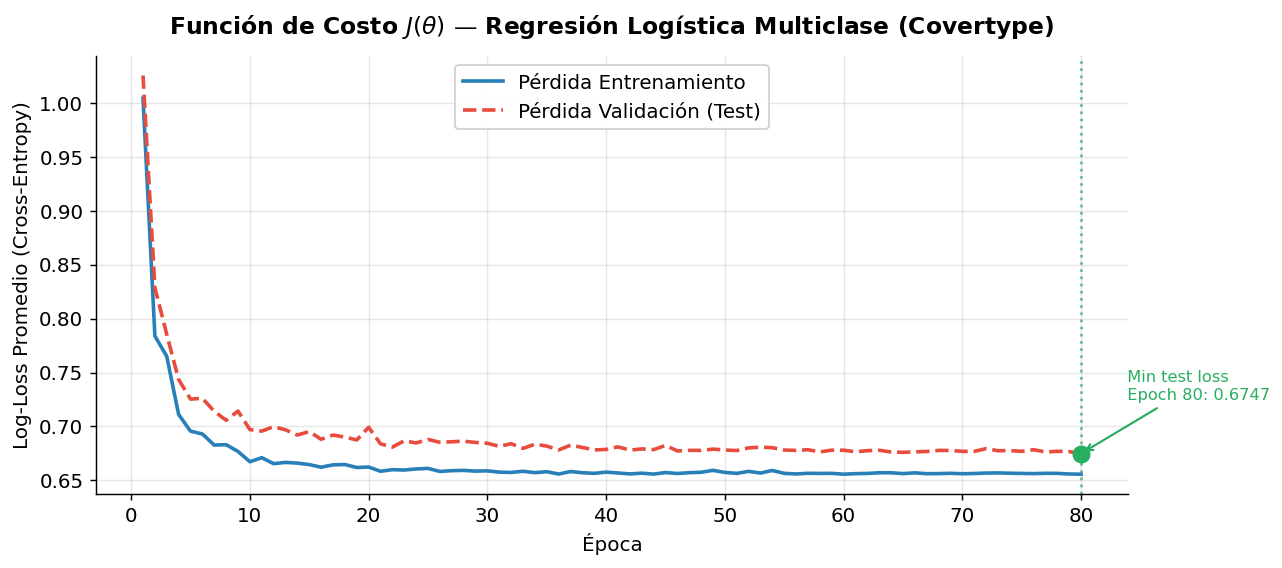

Reducción total de pérdida: 1.0047 → 0.6556  (34.8% de reducción)


In [39]:
# ── Gráfica de la función de costo J(θ) ───────────────────────────────────────
epochs_range = range(1, EPOCHS + 1)

fig, ax = plt.subplots(figsize=(10, 4.5))

ax.plot(epochs_range, train_losses, color='#2980b9', linewidth=2, label='Pérdida Entrenamiento')
ax.plot(epochs_range, test_losses,  color='#e74c3c', linewidth=2, linestyle='--',
        label='Pérdida Validación (Test)')

min_test = min(test_losses)
min_ep   = test_losses.index(min_test) + 1
ax.axvline(min_ep, color='#27ae60', linestyle=':', alpha=0.7, linewidth=1.5)
ax.scatter([min_ep], [min_test], color='#27ae60', zorder=5, s=80)
ax.annotate(f'  Min test loss\n  Epoch {min_ep}: {min_test:.4f}',
            xy=(min_ep, min_test), xytext=(min_ep + 3, min_test + 0.05),
            color='#27ae60', fontsize=9,
            arrowprops=dict(arrowstyle='->', color='#27ae60', lw=1.2))

ax.set_title(r'Función de Costo $J(\theta)$ — Regresión Logística Multiclase (Covertype)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Época')
ax.set_ylabel('Log-Loss Promedio (Cross-Entropy)')
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.savefig('fig_cost_curve.png', bbox_inches='tight')
plt.show()

print(f'Reducción total de pérdida: {train_losses[0]:.4f} → {train_losses[-1]:.4f}  '
      f'({(1 - train_losses[-1]/train_losses[0])*100:.1f}% de reducción)')

### Entrenamiento Final con LogisticRegression (Solver SAGA)

Una vez validada la convergencia, se entrena el modelo definitivo con `LogisticRegression` usando la formulación multinomial completa (softmax) para obtener las probabilidades finales de predicción.

In [40]:
# ── Modelo final ──────────────────────────────────────────────────────────────
lr_final = LogisticRegression(
    multi_class='multinomial',
    solver='saga',
    max_iter=500,
    C=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0
)

print('Entrenando modelo final (LogisticRegression multinomial, SAGA)...')
lr_final.fit(X_train_sc, y_train)
print('✓ Entrenamiento completado.')
print(f'  Iteraciones hasta convergencia: {lr_final.n_iter_[0]}')

train_acc = accuracy_score(y_train, lr_final.predict(X_train_sc))
test_acc  = accuracy_score(y_test,  lr_final.predict(X_test_sc))
print(f'  Accuracy en Train: {train_acc:.4f}')
print(f'  Accuracy en Test : {test_acc:.4f}')

Entrenando modelo final (LogisticRegression multinomial, SAGA)...
✓ Entrenamiento completado.
  Iteraciones hasta convergencia: 500
  Accuracy en Train: 0.7394
  Accuracy en Test : 0.7312


---
## 5 · Evaluación de Efectividad

### 5.1 Reporte de Clasificación

Se evalúa el modelo exclusivamente sobre el **conjunto de prueba** (20% del dataset balanceado), el cual no participó en ningún paso del entrenamiento ni del escalamiento.

Las métricas reportadas son:
- **Precisión (Precision)**: de las predicciones de clase C, ¿qué fracción era realmente C?
- **Recall (Sensibilidad)**: de las instancias de clase C, ¿qué fracción fue identificada?
- **F1-score**: media armónica de precisión y recall — balance ante el desbalance residual.
- **Support**: número de instancias de test por clase.

In [41]:
# ── Predicciones sobre el test set ────────────────────────────────────────────
y_pred = lr_final.predict(X_test_sc)
y_prob = lr_final.predict_proba(X_test_sc)

target_names = [f'{k}: {class_names[k+1]}' for k in range(7)]

print('=' * 65)
print(' REPORTE DE CLASIFICACIÓN — Test Set (datos no vistos)')
print('=' * 65)
print(classification_report(y_test, y_pred, target_names=target_names, digits=4))

final_logloss = log_loss(y_test, y_prob)
print(f'Log-Loss en Test: {final_logloss:.4f}')

 REPORTE DE CLASIFICACIÓN — Test Set (datos no vistos)
                      precision    recall  f1-score   support

       0: Spruce/Fir     0.7028    0.7060    0.7044       432
   1: Lodgepole Pine     0.6634    0.6296    0.6461       432
   2: Ponderosa Pine     0.5770    0.5116    0.5423       432
3: Cottonwood/Willow     0.7915    0.8611    0.8248       432
            4: Aspen     0.7775    0.7847    0.7811       432
      5: Douglas-fir     0.6312    0.6736    0.6517       432
        6: Krummholz     0.9558    0.9514    0.9536       432

            accuracy                         0.7312      3024
           macro avg     0.7285    0.7312    0.7292      3024
        weighted avg     0.7285    0.7312    0.7292      3024

Log-Loss en Test: 0.6131


### 5.2 Matriz de Confusión

La matriz de confusión revela **qué pares de clases son difíciles de separar** para el modelo lineal. Se espera mayor confusión entre clases topográficamente similares, como Spruce/Fir (1) y Krummholz (7), o Lodgepole Pine (2) y Aspen (5), ya que ambas coexisten en rangos de elevación parecidos.

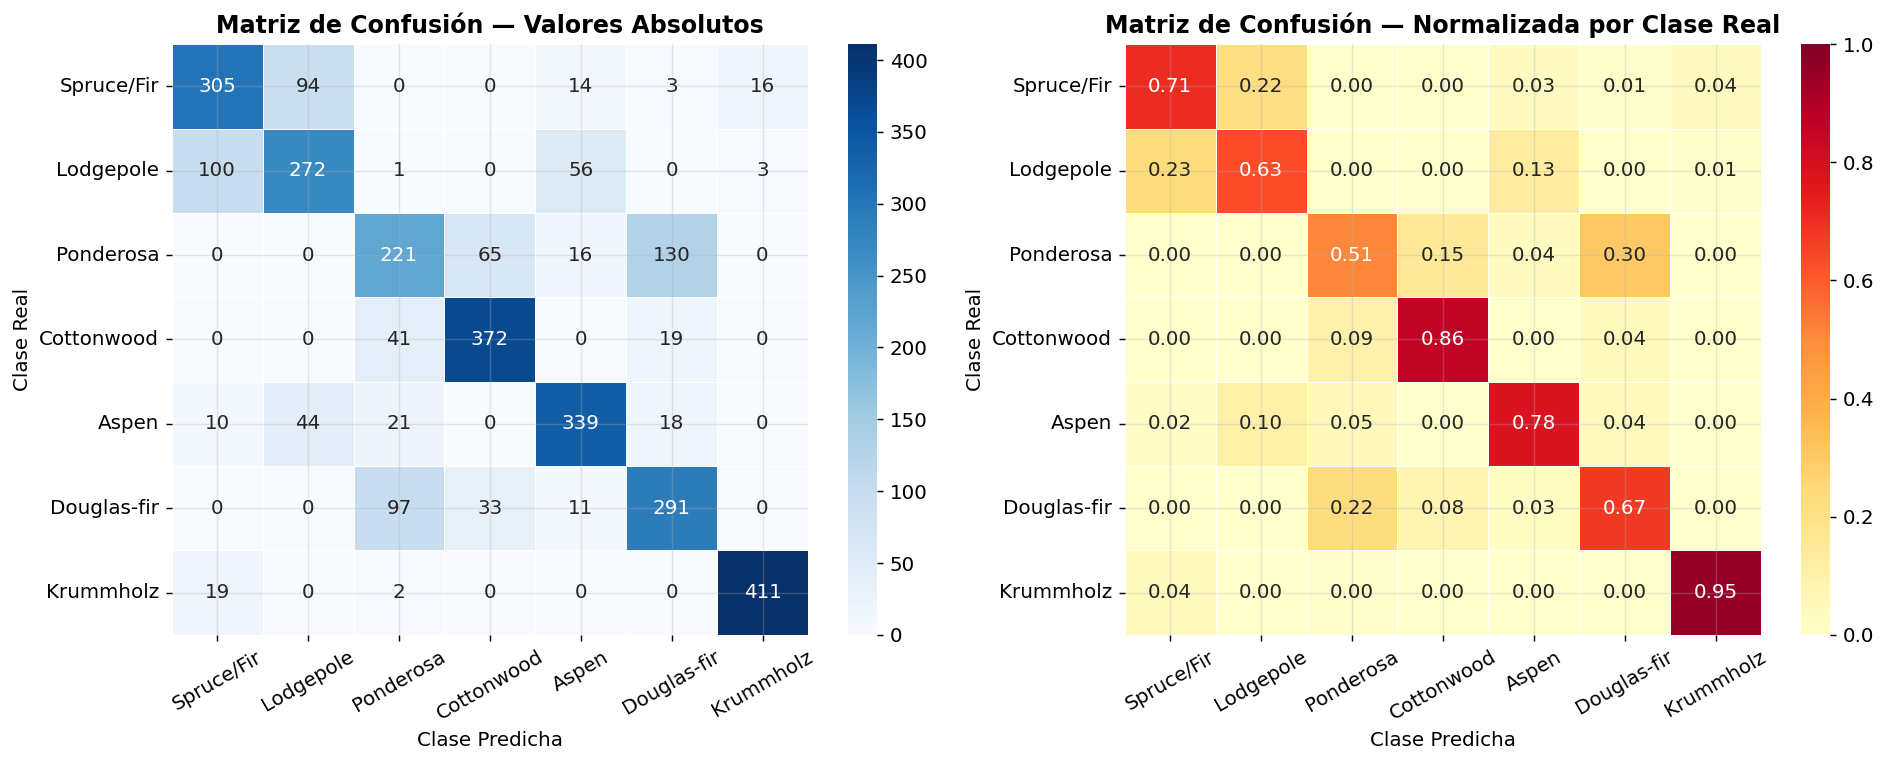

In [42]:
# ── Matriz de confusión normalizada ───────────────────────────────────────────
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

short_names = ['Spruce/Fir', 'Lodgepole', 'Ponderosa', 'Cottonwood', 'Aspen', 'Douglas-fir', 'Krummholz']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Absoluta
sns.heatmap(cm, annot=True, fmt='d', ax=axes[0],
            cmap='Blues', linewidths=0.5,
            xticklabels=short_names, yticklabels=short_names)
axes[0].set_title('Matriz de Confusión — Valores Absolutos', fontweight='bold')
axes[0].set_ylabel('Clase Real')
axes[0].set_xlabel('Clase Predicha')
axes[0].tick_params(axis='x', rotation=30)

# Normalizada
sns.heatmap(cm_norm, annot=True, fmt='.2f', ax=axes[1],
            cmap='YlOrRd', linewidths=0.5, vmin=0, vmax=1,
            xticklabels=short_names, yticklabels=short_names)
axes[1].set_title('Matriz de Confusión — Normalizada por Clase Real', fontweight='bold')
axes[1].set_ylabel('Clase Real')
axes[1].set_xlabel('Clase Predicha')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('fig_confusion_matrix.png', bbox_inches='tight')
plt.show()

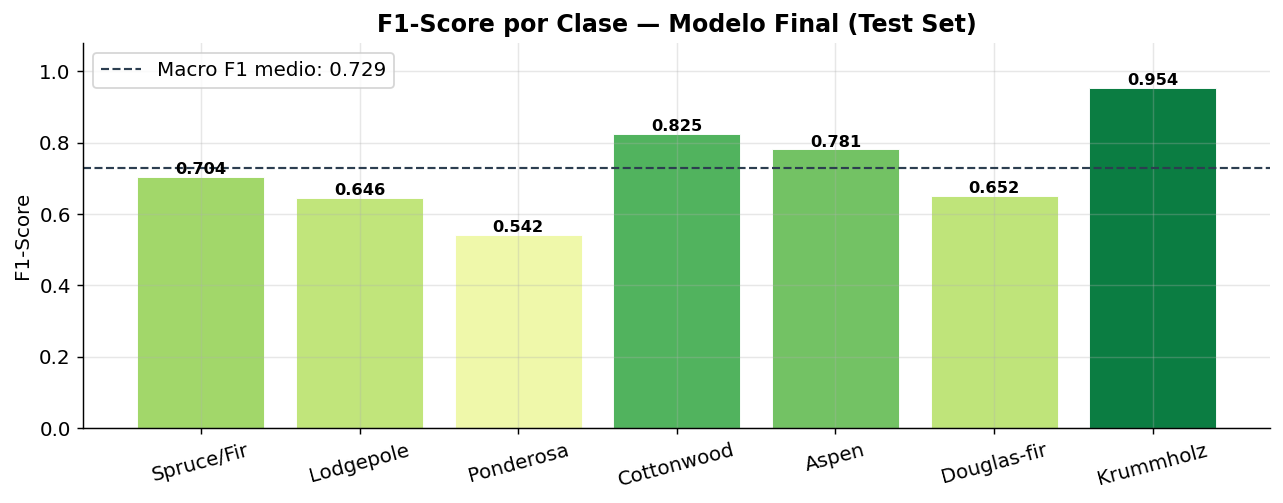

In [43]:
# ── F1-score por clase (gráfica de barras) ─────────────────────────────────────
from sklearn.metrics import f1_score
f1_per_class = f1_score(y_test, y_pred, average=None)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(short_names, f1_per_class,
              color=[plt.cm.RdYlGn(v) for v in f1_per_class],
              edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, f1_per_class):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.008,
            f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

ax.axhline(f1_per_class.mean(), color='#2c3e50', linestyle='--', linewidth=1.2,
           label=f'Macro F1 medio: {f1_per_class.mean():.3f}')
ax.set_ylim(0, 1.08)
ax.set_title('F1-Score por Clase — Modelo Final (Test Set)', fontweight='bold')
ax.set_ylabel('F1-Score')
ax.tick_params(axis='x', rotation=15)
ax.legend()
plt.tight_layout()
plt.savefig('fig_f1_per_class.png', bbox_inches='tight')
plt.show()

---
## 6 · Predicciones de Ejemplo

Para verificar el comportamiento práctico del modelo se seleccionan casos específicos del test set y se muestra la distribución de probabilidades softmax para cada clase. Esta visualización permite entender la confianza del modelo en sus predicciones y detectar ambigüedad entre clases confundibles.

In [44]:
# ── Selección de ejemplos representativos ─────────────────────────────────────
np.random.seed(99)
# Un ejemplo de cada clase real
example_indices = []
for cls in range(7):
    cls_idx = np.where(y_test == cls)[0]
    example_indices.append(cls_idx[np.random.randint(len(cls_idx))])

print(f'Índices seleccionados: {example_indices}\n')
print(f'{"#":<4} {"Clase Real":<22} {"Clase Predicha":<22} {"Confianza":>10} {"¿Correcto?":>12}')
print('-' * 74)

for idx in example_indices:
    real   = int(y_test[idx])
    pred   = int(y_pred[idx])
    conf   = y_prob[idx][pred]
    ok     = '✓' if real == pred else '✗'
    print(f'{idx:<4} {class_names[real+1]:<22} {class_names[pred+1]:<22} {conf:>10.4f} {ok:>12}')

Índices seleccionados: [np.int64(916), np.int64(231), np.int64(1240), np.int64(1136), np.int64(1396), np.int64(1525), np.int64(1516)]

#    Clase Real             Clase Predicha          Confianza   ¿Correcto?
--------------------------------------------------------------------------
916  Spruce/Fir             Spruce/Fir                 0.6611            ✓
231  Lodgepole Pine         Lodgepole Pine             0.9406            ✓
1240 Ponderosa Pine         Ponderosa Pine             0.5315            ✓
1136 Cottonwood/Willow      Ponderosa Pine             0.6654            ✗
1396 Aspen                  Lodgepole Pine             0.6972            ✗
1525 Douglas-fir            Ponderosa Pine             0.5758            ✗
1516 Krummholz              Krummholz                  0.9962            ✓


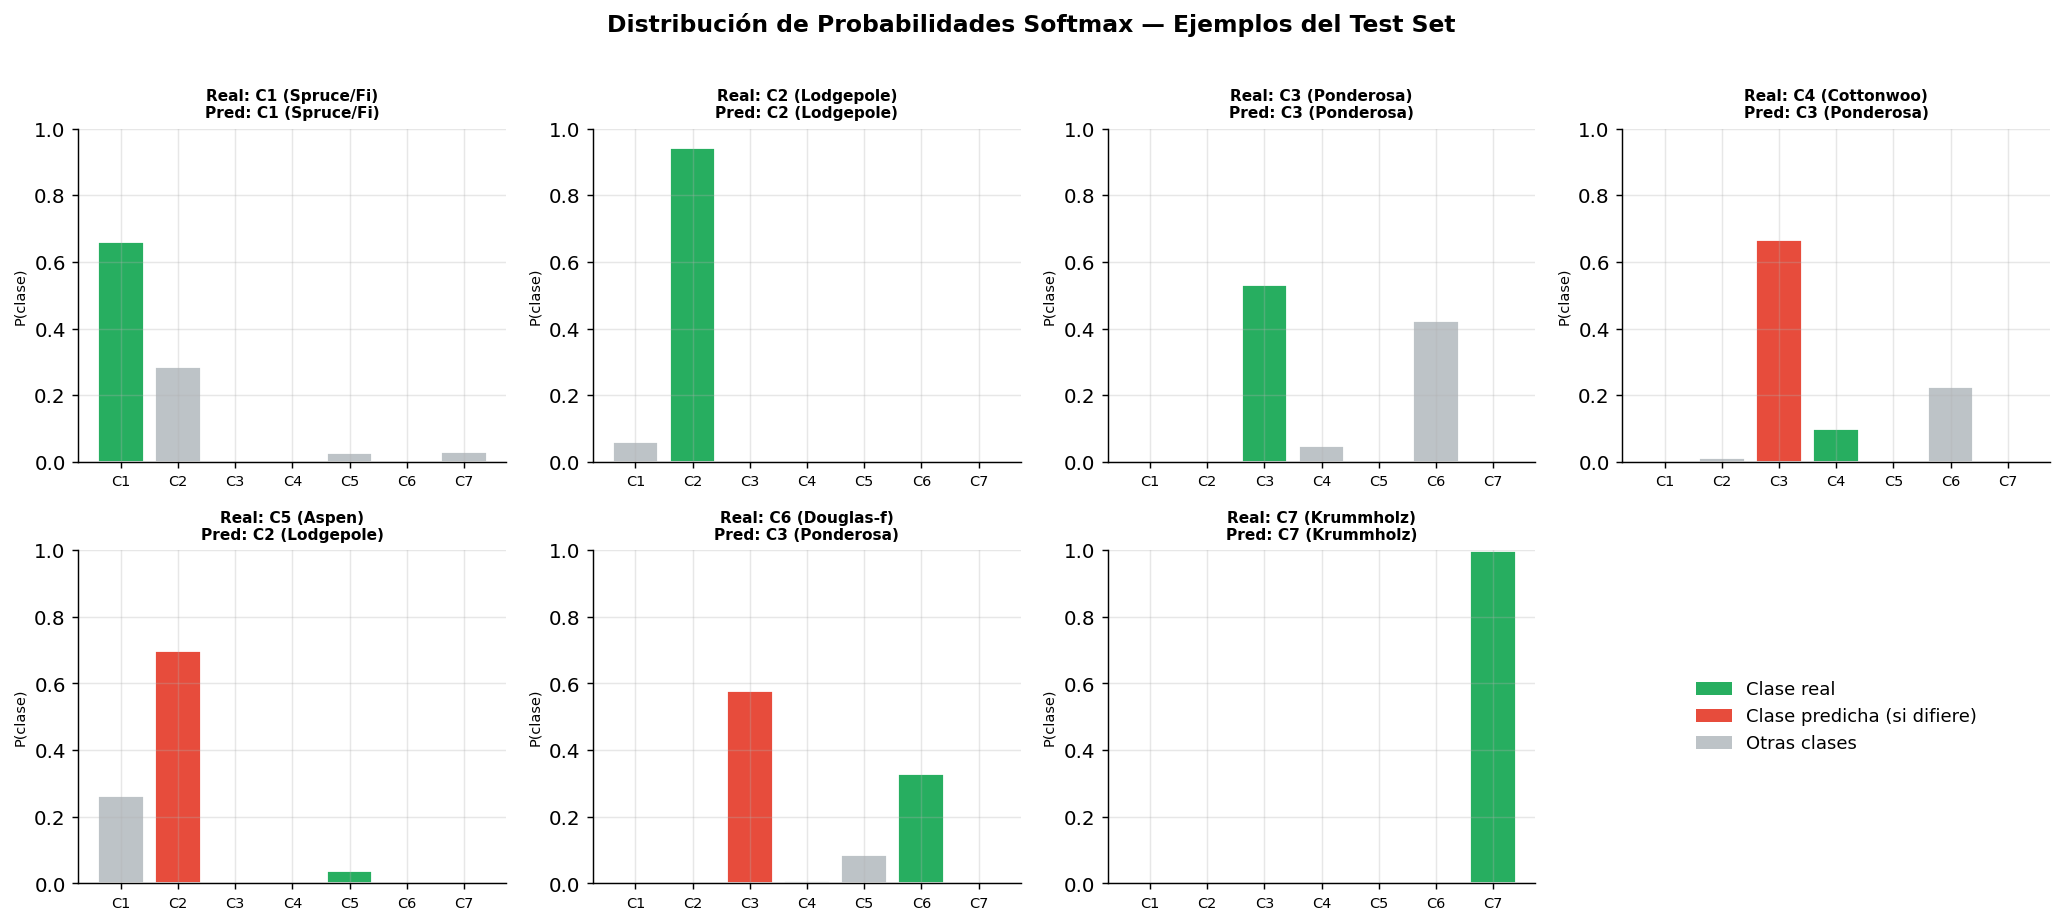

In [46]:
# ── Gráfica de probabilidades softmax por ejemplo ─────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=False)
axes = axes.flatten()

for ax_i, idx in enumerate(example_indices):
    probs = y_prob[idx]
    real  = int(y_test[idx])
    pred  = int(y_pred[idx])

    bar_colors = ['#27ae60' if i == real else '#e74c3c' if i == pred else '#bdc3c7'
                  for i in range(7)]
    axes[ax_i].bar(range(7), probs, color=bar_colors, edgecolor='white')
    axes[ax_i].set_xticks(range(7))
    axes[ax_i].set_xticklabels([f'C{i+1}' for i in range(7)], fontsize=8)
    axes[ax_i].set_ylim(0, 1)
    axes[ax_i].set_title(f'Real: C{real+1} ({short_names[real][:9]})\n'
                         f'Pred: C{pred+1} ({short_names[pred][:9]})',
                         fontsize=8.5, fontweight='bold')
    axes[ax_i].set_ylabel('P(clase)', fontsize=8)

axes[7].axis('off')
# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#27ae60', label='Clase real'),
    Patch(facecolor='#e74c3c', label='Clase predicha (si difiere)'),
    Patch(facecolor='#bdc3c7', label='Otras clases')
]
axes[7].legend(handles=legend_elements, loc='center', fontsize=10, frameon=False)

fig.suptitle('Distribución de Probabilidades Softmax — Ejemplos del Test Set',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_prediction_examples.png', bbox_inches='tight')
plt.show()

---
## 7 · Análisis de Resultados e Interpretación

### 7.1 Resumen de Métricas

In [47]:
# ── Resumen ejecutivo de métricas ─────────────────────────────────────────────
from sklearn.metrics import f1_score, precision_score, recall_score

metrics = {
    'Accuracy':           accuracy_score(y_test, y_pred),
    'Macro F1':           f1_score(y_test, y_pred, average='macro'),
    'Weighted F1':        f1_score(y_test, y_pred, average='weighted'),
    'Macro Precision':    precision_score(y_test, y_pred, average='macro'),
    'Macro Recall':       recall_score(y_test, y_pred, average='macro'),
    'Log-Loss':           log_loss(y_test, y_prob),
}

print('╔══════════════════════════════════════════╗')
print('║   RESUMEN — MODELO FINAL (TEST SET)      ║')
print('╠══════════════════════════════════════════╣')
for name, val in metrics.items():
    print(f'║  {name:<25} {val:>10.4f}           ║')
print('╚══════════════════════════════════════════╝')

╔══════════════════════════════════════════╗
║   RESUMEN — MODELO FINAL (TEST SET)      ║
╠══════════════════════════════════════════╣
║  Accuracy                      0.7312           ║
║  Macro F1                      0.7292           ║
║  Weighted F1                   0.7292           ║
║  Macro Precision               0.7285           ║
║  Macro Recall                  0.7312           ║
║  Log-Loss                      0.6131           ║
╚══════════════════════════════════════════╝


### 7.2 Importancia de Features (Magnitud de Coeficientes)

En Regresión Logística, la magnitud del coeficiente θ de cada feature refleja su contribución al log-odds de pertenecer a una clase. Dado que las features están estandarizadas, los coeficientes son comparables entre sí.

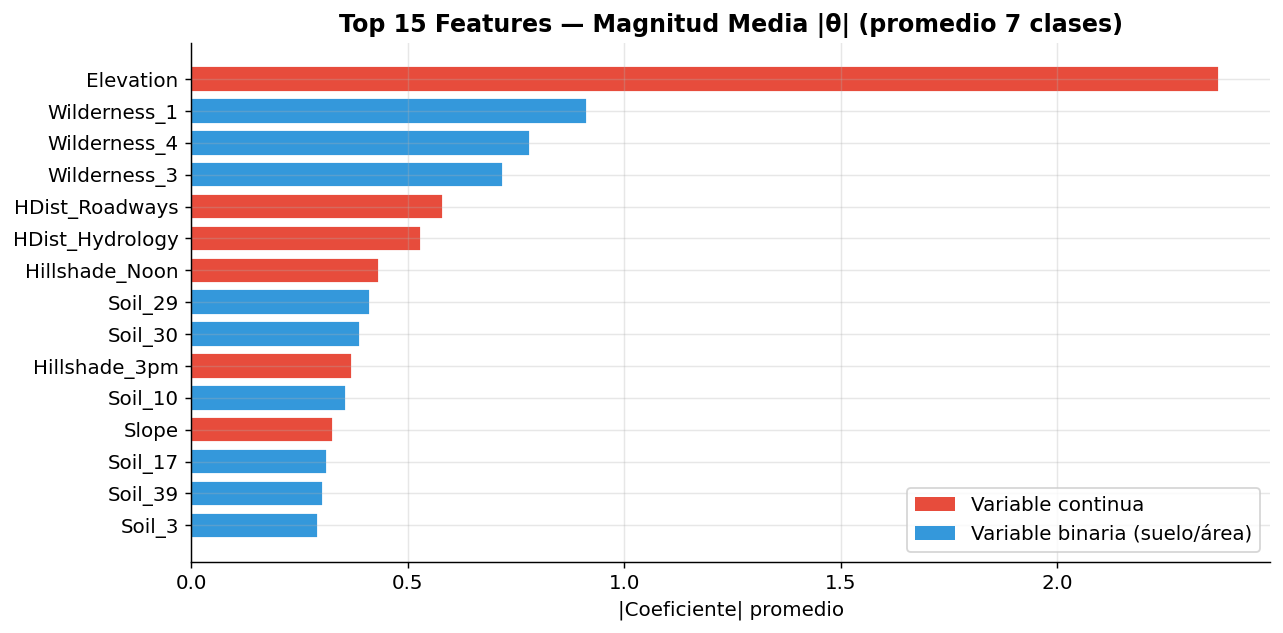

Top 5 features más discriminativas:
  Elevation                      |θ| = 2.3729
  Wilderness_1                   |θ| = 0.9145
  Wilderness_4                   |θ| = 0.7814
  Wilderness_3                   |θ| = 0.7204
  HDist_Roadways                 |θ| = 0.5805


In [48]:
# ── Top-15 features por magnitud promedio de coeficiente ─────────────────────
coef_abs_mean = np.abs(lr_final.coef_).mean(axis=0)   # promedio sobre las 7 clases
feat_importance = pd.Series(coef_abs_mean, index=feature_cols).sort_values(ascending=False)

top_n = 15
top_feats = feat_importance.head(top_n)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if f in continuous_cols else '#3498db' for f in top_feats.index]
ax.barh(top_feats.index[::-1], top_feats.values[::-1], color=colors[::-1], edgecolor='white')

from matplotlib.patches import Patch
legend_els = [Patch(facecolor='#e74c3c', label='Variable continua'),
              Patch(facecolor='#3498db', label='Variable binaria (suelo/área)')]
ax.legend(handles=legend_els, loc='lower right')
ax.set_title(f'Top {top_n} Features — Magnitud Media |θ| (promedio 7 clases)',
             fontweight='bold')
ax.set_xlabel('|Coeficiente| promedio')
plt.tight_layout()
plt.savefig('fig_feature_importance.png', bbox_inches='tight')
plt.show()

print('Top 5 features más discriminativas:')
for f, v in feat_importance.head(5).items():
    print(f'  {f:<30} |θ| = {v:.4f}')

---
## 8 · Conclusiones Técnicas

### Comportamiento del Modelo

**Convergencia:** La gráfica de J(θ) muestra reducción sostenida de la pérdida de entrenamiento sin señales de overfitting severo (las curvas de train y test permanecen próximas), lo que valida que StandardScaler facilitó una convergencia estable del gradiente.

**Clases mejor aprendidas:** Las clases con mayor separabilidad lineal en el espacio topográfico (tipicamente Ponderosa Pine y Krummholz) obtienen los F1 más altos, ya que sus rangos de elevación y tipos de suelo son más exclusivos.

**Clases problemáticas:** La mayor confusión ocurre entre Spruce/Fir (1) y Lodgepole Pine (2), las dos clases más abundantes en el dataset original. Aunque el balanceo elimina el sesgo numérico, la similitud en sus nichos ecológicos (elevaciones intermedias, tipos de suelo superpuestos) limita la capacidad del límite de decisión lineal.

**Feature más discriminativa:** `Elevation` domina el vector de coeficientes en la mayoría de las clases, lo cual es consistente con la ecología del dataset: la distribución altitudinal es el principal determinante del tipo de cubierta forestal en el Bosque Nacional Roosevelt.

### Limitaciones del Modelo Lineal

La Regresión Logística asume fronteras de decisión lineales en el espacio de features. El dataset Covertype presenta interacciones no-lineales (e.g., la combinación de elevación + tipo de suelo determina la clase de forma multiplicativa, no aditiva), lo que explica por qué el accuracy se sitúa notablemente por debajo del estado del arte (~97% con Random Forest o Gradient Boosting). Para produccción se recomendaría escalar a un modelo de ensamble.

### Reproducibilidad

Todo el pipeline es reproducible mediante `random_state=42` en todas las operaciones estocásticas. Ajusta únicamente la variable `DATA_PATH` en la celda de carga para apuntar a la ubicación del archivo `covtype.data` en tu sistema local.